<div>
Olá, Iago!

Meu nome é Luiz. Fico feliz em revisar seu projeto. Ao longo do texto farei algumas observações sobre melhorias no código e também farei comentários sobre suas percepções sobre o assunto. Estarei aberto a feedbacks e discussões sobre o tema.

**Peço que mantenha e não altere os comentários que eu fizer por aqui para que possamos nos localizar posteriormente, ok?**

Mais uma coisa, vamos utilizar um código de cores para você entender o meu feedback no seu notebook. Funciona assim:

<div class="alert alert-block alert-success">
<b> Comentário do revisor: </b> <a class="tocSkip"></a>

Sucesso. Tudo foi feito corretamente.
</div>

<div class="alert alert-block alert-warning">
<b>Comentário do revisor: </b> <a class="tocSkip"></a>

Alerta não crítico, mas que pode ser corrigido para melhoria geral no seu código/análise.
</div>

<div class="alert alert-block alert-danger">

<b>Comentário do revisor: </b> <a class="tocSkip"></a>
    
Erro que precisa ser arrumado, caso contrário seu projeto **não** será aceito.
</div>

Você pode interagir comigo através dessa célula:
<div class="alert alert-block alert-info">
<b>Resposta do Aluno.</b> <a class="tocSkip"></a>
</div>

<div class="alert alert-block alert-success">
<b> Comentário geral do revisor</b> <a class="tocSkip"></a>

Obrigado por enviar o seu projeto e pelo esforço de chegar até aqui. Essa versão do seu trabalho ficou muito boa! Espero que as sugestões sejam relevantes para projetos futuros.
    
<br>
Te desejo uma jornada de muito sucesso e aprendizado.
    
<br>   
    
Qualquer dúvida, pode contar comigo.   
    
<br>  
    
**Até breve!**

</div>

# Projeto Final — Etapa 2: Código da Solução

## Previsão da temperatura final do metal na Steelproof

Nesta etapa, será implementada a solução proposta no plano de trabalho para prever a temperatura final do metal durante o processamento do aço na planta Steelproof.

O objetivo é construir um processo analítico reproduzível, partindo dos dados brutos de diferentes fontes operacionais até a criação e avaliação de modelos preditivos confiáveis.

As principais etapas deste notebook serão:
1. carregar e inspecionar os dados;
2. tratar inconsistências, ausências e tipos de variáveis;
3. consolidar uma base analítica por lote (`key`);
4. definir a variável-alvo e os atributos preditores;
5. preparar os dados para modelagem;
6. treinar, validar e comparar diferentes modelos de regressão;
7. interpretar os resultados no contexto do negócio.

## 1. Importação de bibliotecas

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 200)
pd.set_option('display.width', 120)
pd.set_option('display.float_format', '{:.2f}'.format)

RANDOM_STATE = 42

## 2. Carregamento dos dados

In [2]:
data_arc = pd.read_csv('CSV Archives/data_arc_en.csv')
data_bulk = pd.read_csv('CSV Archives/data_bulk_en.csv')
data_bulk_time = pd.read_csv('CSV Archives/data_bulk_time_en.csv')
data_gas = pd.read_csv('CSV Archives/data_gas_en.csv')
data_temp = pd.read_csv('CSV Archives/data_temp_en.csv')
data_wire = pd.read_csv('CSV Archives/data_wire_en.csv')
data_wire_time = pd.read_csv('CSV Archives/data_wire_time_en.csv')

In [3]:
datasets = {
    'data_arc': data_arc,
    'data_bulk': data_bulk,
    'data_bulk_time': data_bulk_time,
    'data_gas': data_gas,
    'data_temp': data_temp,
    'data_wire': data_wire,
    'data_wire_time': data_wire_time
}

for name, df in datasets.items():
    print(f'{name}: {df.shape}')

data_arc: (14876, 5)
data_bulk: (3129, 16)
data_bulk_time: (3129, 16)
data_gas: (3239, 2)
data_temp: (15907, 3)
data_wire: (3081, 10)
data_wire_time: (3081, 10)


## 3. Inspeção inicial dos dados

Antes de iniciar a limpeza e a consolidação da base analítica, é importante confirmar a estrutura dos datasets, seus tipos de dados e a presença de valores ausentes.

Como definido no plano de trabalho, a modelagem será feita no nível do lote (`key`), portanto as diferentes fontes precisarão ser transformadas e agregadas de modo consistente.

In [4]:
for name, df in datasets.items():
    print(f'\n{name}')
    display(df.head())


data_arc


,key,Arc heating start,Arc heating end,Active power,Reactive power
0,1,2019-05-03 11:02:14,2019-05-03 11:06:02,0.98,0.69
1,1,2019-05-03 11:07:28,2019-05-03 11:10:33,0.81,0.52
2,1,2019-05-03 11:11:44,2019-05-03 11:14:36,0.74,0.50
3,1,2019-05-03 11:18:14,2019-05-03 11:24:19,1.66,1.06
4,1,2019-05-03 11:26:09,2019-05-03 11:28:37,0.69,0.41



data_bulk


,key,Bulk 1,Bulk 2,Bulk 3,Bulk 4,Bulk 5,Bulk 6,Bulk 7,Bulk 8,Bulk 9,Bulk 10,Bulk 11,Bulk 12,Bulk 13,Bulk 14,Bulk 15
0,1,NaN,NaN,NaN,43.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,206.00,NaN,150.00,154.00
1,2,NaN,NaN,NaN,73.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,206.00,NaN,149.00,154.00
2,3,NaN,NaN,NaN,34.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,205.00,NaN,152.00,153.00
3,4,NaN,NaN,NaN,81.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,207.00,NaN,153.00,154.00
4,5,NaN,NaN,NaN,78.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,203.00,NaN,151.00,152.00



data_bulk_time


...

,key,Sampling time,Temperature
0,1,2019-05-03 11:16:18,1571.00
1,1,2019-05-03 11:25:53,1604.00
2,1,2019-05-03 11:29:11,1618.00
3,1,2019-05-03 11:30:01,1601.00
4,1,2019-05-03 11:30:39,1613.00



data_wire


,key,Wire 1,Wire 2,Wire 3,Wire 4,Wire 5,Wire 6,Wire 7,Wire 8,Wire 9
0,1,60.06,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,96.05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,3,91.16,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,4,89.06,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,5,89.24,9.11,NaN,NaN,NaN,NaN,NaN,NaN,NaN



data_wire_time


,key,Wire 1,Wire 2,Wire 3,Wire 4,Wire 5,Wire 6,Wire 7,Wire 8,Wire 9
0,1,2019-05-03 11:11:41,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,2019-05-03 11:46:10,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,3,2019-05-03 12:13:47,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,4,2019-05-03 12:48:05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,5,2019-05-03 13:18:15,2019-05-03 13:32:06,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
for name, df in datasets.items():
    print(f'\n{name}')
    print(df.info())
    print('\nValores ausentes por coluna:')
    print(df.isna().sum())
    print('=' * 100)


data_arc
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14876 entries, 0 to 14875
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   key                14876 non-null  int64  
 1   Arc heating start  14876 non-null  object 
 2   Arc heating end    14876 non-null  object 
 3   Active power       14876 non-null  float64
 4   Reactive power     14876 non-null  float64
dtypes: float64(2), int64(1), object(2)
memory usage: 581.2+ KB
None

Valores ausentes por coluna:
key                  0
Arc heating start    0
Arc heating end      0
Active power         0
Reactive power       0
dtype: int64

data_bulk
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3129 entries, 0 to 3128
Data columns (total 16 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   key      3129 non-null   int64  
 1   Bulk 1   252 non-null    float64
 2   Bulk 2   22 non-null     float64
 3   Bulk 3

<div class="alert alert-block alert-warning">
<b> Comentário do revisor: </b> <a class="tocSkip"></a>
    
- Os dados foram carregados corretamente e uma exploração inicial foi executada.
- Como sugestão, você poderia analisar os dados acima e plotar gráficos para verificar a distribuição dos dados.
</div>


## 4. Conversão de tipos e preparação inicial

Conforme observado na etapa de planejamento, os datasets contêm colunas temporais armazenadas como texto. Antes de criar os atributos e consolidar a base final, essas colunas precisam ser convertidas para o tipo `datetime`.

Além disso, a definição da variável-alvo depende da ordenação temporal correta das medições de temperatura por lote.

In [6]:
data_arc['Arc heating start'] = pd.to_datetime(data_arc['Arc heating start'])
data_arc['Arc heating end'] = pd.to_datetime(data_arc['Arc heating end'])

data_temp['Sampling time'] = pd.to_datetime(data_temp['Sampling time'])

In [7]:
bulk_time_columns = [col for col in data_bulk_time.columns if col != 'key']
wire_time_columns = [col for col in data_wire_time.columns if col != 'key']

for col in bulk_time_columns:
    data_bulk_time[col] = pd.to_datetime(data_bulk_time[col], errors='coerce')

for col in wire_time_columns:
    data_wire_time[col] = pd.to_datetime(data_wire_time[col], errors='coerce')

In [8]:
print(data_arc.info())
print('\n')
print(data_temp.info())
print('\n')
print(data_bulk_time.info())
print('\n')
print(data_wire_time.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14876 entries, 0 to 14875
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   key                14876 non-null  int64         
 1   Arc heating start  14876 non-null  datetime64[ns]
 2   Arc heating end    14876 non-null  datetime64[ns]
 3   Active power       14876 non-null  float64       
 4   Reactive power     14876 non-null  float64       
dtypes: datetime64[ns](2), float64(2), int64(1)
memory usage: 581.2 KB
None


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15907 entries, 0 to 15906
Data columns (total 3 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   key            15907 non-null  int64         
 1   Sampling time  15907 non-null  datetime64[ns]
 2   Temperature    13006 non-null  float64       
dtypes: datetime64[ns](1), float64(1), int64(1)
memory usage: 372.

## 5. Definição da variável-alvo e atributos de temperatura

De acordo com o plano de trabalho, a variável-alvo será a **temperatura final por lote**, definida como a última medição disponível em `data_temp` para cada `key`.

Também será criada a temperatura inicial do lote, pois ela é uma candidata natural a forte preditor da temperatura final.

In [9]:
temp_sorted = data_temp.sort_values(['key', 'Sampling time']).copy()

first_temp = temp_sorted.groupby('key').first().reset_index()
last_temp = temp_sorted.groupby('key').last().reset_index()

temp_features = pd.DataFrame({
    'key': first_temp['key'],
    'temp_initial': first_temp['Temperature'],
    'temp_final': last_temp['Temperature'],
    'time_first_measurement': first_temp['Sampling time'],
    'time_last_measurement': last_temp['Sampling time']
})

temp_features['process_time_min'] = (
    temp_features['time_last_measurement'] - temp_features['time_first_measurement']
).dt.total_seconds() / 60

temp_features.head()

,key,temp_initial,temp_final,time_first_measurement,time_last_measurement,process_time_min
0,1,1571.00,1613.00,2019-05-03 11:16:18,2019-05-03 11:30:39,14.35
1,2,1581.00,1602.00,2019-05-03 11:37:27,2019-05-03 11:59:12,21.75
2,3,1596.00,1599.00,2019-05-03 12:13:17,2019-05-03 12:34:57,21.67
3,4,1601.00,1625.00,2019-05-03 12:52:57,2019-05-03 12:59:25,6.47
4,5,1576.00,1602.00,2019-05-03 13:23:19,2019-05-03 13:36:01,12.70


In [10]:
print('Lotes na base de temperatura:', temp_features['key'].nunique())
print('Ausentes em temp_initial:', temp_features['temp_initial'].isna().sum())
print('Ausentes em temp_final:', temp_features['temp_final'].isna().sum())
print('Ausentes em process_time_min:', temp_features['process_time_min'].isna().sum())

Lotes na base de temperatura: 3216
Ausentes em temp_initial: 0
Ausentes em temp_final: 0
Ausentes em process_time_min: 0


In [11]:
temp_features[['temp_initial', 'temp_final', 'process_time_min']].describe()

,temp_initial,temp_final,process_time_min
count,3216.00,3216.00,3216.00
mean,1588.59,1593.93,30.66
std,29.14,19.87,20.78
min,1191.00,1204.00,0.00
25%,1572.00,1585.00,19.62
50%,1588.00,1593.00,26.35
75%,1606.00,1600.00,37.25
max,1684.00,1700.00,392.28


## 6. Engenharia de atributos a partir do aquecimento elétrico

O dataset `data_arc` contém registros de múltiplos eventos de aquecimento por lote. Como a modelagem será feita no nível do lote, esses registros serão agregados para gerar atributos operacionais como:

- número de eventos de aquecimento;
- potência ativa média e total;
- potência reativa média e total;
- duração total e média do aquecimento.

In [12]:
data_arc['heating_duration_min'] = (
    (data_arc['Arc heating end'] - data_arc['Arc heating start']).dt.total_seconds() / 60
)

In [13]:
arc_agg = data_arc.groupby('key').agg(
    arc_events=('key', 'count'),
    active_power_mean=('Active power', 'mean'),
    active_power_sum=('Active power', 'sum'),
    reactive_power_mean=('Reactive power', 'mean'),
    reactive_power_sum=('Reactive power', 'sum'),
    heating_duration_total_min=('heating_duration_min', 'sum'),
    heating_duration_mean_min=('heating_duration_min', 'mean')
).reset_index()

arc_agg.head()

,key,arc_events,active_power_mean,active_power_sum,reactive_power_mean,reactive_power_sum,heating_duration_total_min,heating_duration_mean_min
0,1,5,0.98,4.88,0.64,3.18,18.30,3.66
1,2,4,0.76,3.05,0.50,2.00,13.52,3.38
2,3,5,0.51,2.53,0.32,1.60,10.92,2.18
3,4,4,0.80,3.21,0.52,2.06,12.35,3.09
4,5,4,0.84,3.35,0.56,2.25,14.48,3.62


In [14]:
arc_agg.describe()

,key,arc_events,active_power_mean,active_power_sum,reactive_power_mean,reactive_power_sum,heating_duration_total_min,heating_duration_mean_min
count,3214.00,3214.00,3214.00,3214.00,3214.00,3214.00,3214.00,3214.00
mean,1623.06,4.63,0.67,3.10,0.45,2.09,13.24,2.87
std,934.74,1.61,0.21,1.40,3.16,12.69,5.54,0.76
min,1.00,1.00,0.19,0.19,-178.65,-714.59,0.95,0.95
25%,817.25,4.00,0.52,2.13,0.39,1.60,9.52,2.33
50%,1623.50,4.00,0.65,2.99,0.49,2.23,12.83,2.81
75%,2431.75,6.00,0.80,3.90,0.60,2.90,16.38,3.34
max,3241.00,16.00,1.82,17.50,1.14,12.59,69.82,6.33


## 7. Preparação dos datasets de materiais e gás

Os datasets de materiais a granel, materiais em arame e gás já estão próximos de uma estrutura por lote. Nesta etapa, será verificado se há necessidade de agregação adicional e eles serão preparados para junção com a base principal.

In [15]:
print('Duplicados em data_bulk por key:', data_bulk['key'].duplicated().sum())
print('Duplicados em data_bulk_time por key:', data_bulk_time['key'].duplicated().sum())
print('Duplicados em data_gas por key:', data_gas['key'].duplicated().sum())
print('Duplicados em data_wire por key:', data_wire['key'].duplicated().sum())
print('Duplicados em data_wire_time por key:', data_wire_time['key'].duplicated().sum())

Duplicados em data_bulk por key: 0
Duplicados em data_bulk_time por key: 0
Duplicados em data_gas por key: 0
Duplicados em data_wire por key: 0
Duplicados em data_wire_time por key: 0


In [16]:
bulk_time_features = pd.DataFrame({'key': data_bulk_time['key']})
wire_time_features = pd.DataFrame({'key': data_wire_time['key']})

bulk_time_features['bulk_additions_count'] = data_bulk_time[bulk_time_columns].notna().sum(axis=1)
wire_time_features['wire_additions_count'] = data_wire_time[wire_time_columns].notna().sum(axis=1)

bulk_time_features['bulk_time_span_min'] = (
    data_bulk_time[bulk_time_columns].max(axis=1) - data_bulk_time[bulk_time_columns].min(axis=1)
).dt.total_seconds() / 60

wire_time_features['wire_time_span_min'] = (
    data_wire_time[wire_time_columns].max(axis=1) - data_wire_time[wire_time_columns].min(axis=1)
).dt.total_seconds() / 60

bulk_time_features.head()

,key,bulk_additions_count,bulk_time_span_min
0,1,4,17.63
1,2,4,6.30
2,3,4,21.43
3,4,4,7.32
4,5,4,5.90


In [17]:
wire_time_features.head()

,key,wire_additions_count,wire_time_span_min
0,1,1,0.00
1,2,1,0.00
2,3,1,0.00
3,4,1,0.00
4,5,2,13.85


## 8. Consolidação da base analítica por lote

Nesta etapa, os dados de temperatura, aquecimento, materiais e gás serão integrados em uma única tabela por `key`. Essa base consolidada será usada nas próximas etapas de limpeza final, preparação e modelagem.

In [18]:
final_data = (
    temp_features
    .merge(arc_agg, on='key', how='left')
    .merge(data_bulk, on='key', how='left')
    .merge(bulk_time_features, on='key', how='left')
    .merge(data_gas, on='key', how='left')
    .merge(data_wire, on='key', how='left')
    .merge(wire_time_features, on='key', how='left')
)

final_data.head()

,key,temp_initial,temp_final,time_first_measurement,time_last_measurement,process_time_min,arc_events,active_power_mean,active_power_sum,reactive_power_mean,reactive_power_sum,heating_duration_total_min,heating_duration_mean_min,Bulk 1,Bulk 2,Bulk 3,Bulk 4,Bulk 5,Bulk 6,Bulk 7,Bulk 8,Bulk 9,Bulk 10,Bulk 11,Bulk 12,Bulk 13,Bulk 14,Bulk 15,bulk_additions_count,bulk_time_span_min,Gas 1,Wire 1,Wire 2,Wire 3,Wire 4,Wire 5,Wire 6,Wire 7,Wire 8,Wire 9,wire_additions_count,wire_time_span_min
0,1,1571.00,1613.00,2019-05-03 11:16:18,2019-05-03 11:30:39,14.35,5.00,0.98,4.88,0.64,3.18,18.30,3.66,NaN,NaN,NaN,43.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,206.00,NaN,150.00,154.00,4.00,17.63,29.75,60.06,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.00,0.00
1,2,1581.00,1602.00,2019-05-03 11:37:27,2019-05-03 11:59:12,21.75,4.00,0.76,3.05,0.50,2.00,13.52,3.38,NaN,NaN,NaN,73.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,206.00,NaN,149.00,154.00,4.00,6.30,12.56,96.05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.00,0.00
2,3,1596.00,1599.00,2019-05-03 12:13:17,2019-05-03 12:34:57,21.67,5.00,0.51,2.53,0.32,1.60,10.92,2.18,NaN,NaN,NaN,34.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,205.00,NaN,152.00,153.00,4.00,21.43,28.55,91.16,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.00,0.00
3,4,1601.00,1625.00,2019-05-03 12:52:57,2019-05-03 12:59:25,6.47,4.00,0.80,3.21,0.52,2.06,12.35,3.09,NaN,NaN,NaN,81.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,207.00,NaN,153.00,154.00,4.00,7.32,18.84,89.06,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.00,0.00
4,5,1576.00,1602.00,2019-05-03 13:23:19,2019-05-03 13:36:01,12.70,4.00,0.84,3.35,0.56,2.25,14.48,3.62,NaN,NaN,NaN,78.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,203.00,NaN,151.00,152.00,4.00,5.90,5.41,89.24,9.11,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.00,13.85


In [19]:
final_data.shape

(3216, 42)

In [20]:
final_data.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 3216 entries, 0 to 3215
Data columns (total 42 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   key                         3216 non-null   int64         
 1   temp_initial                3216 non-null   float64       
 2   temp_final                  3216 non-null   float64       
 3   time_first_measurement      3216 non-null   datetime64[ns]
 4   time_last_measurement       3216 non-null   datetime64[ns]
 5   process_time_min            3216 non-null   float64       
 6   arc_events                  3214 non-null   float64       
 7   active_power_mean           3214 non-null   float64       
 8   active_power_sum            3214 non-null   float64       
 9   reactive_power_mean         3214 non-null   float64       
 10  reactive_power_sum          3214 non-null   float64       
 11  heating_duration_total_min  3214 non-null   float64     

In [21]:
final_data.isna().sum().sort_values(ascending=False).head(30)

Bulk 8                       3215
Wire 5                       3215
Wire 7                       3205
Wire 4                       3202
Bulk 13                      3198
Bulk 9                       3197
Wire 8                       3197
Bulk 2                       3194
Bulk 7                       3191
Wire 9                       3187
Wire 3                       3153
Wire 6                       3143
Bulk 5                       3139
Bulk 10                      3040
Bulk 11                      3039
Bulk 1                       2964
Bulk 6                       2640
Bulk 4                       2202
Wire 2                       2137
Bulk 3                       1918
Bulk 15                       968
Bulk 12                       766
Bulk 14                       410
Wire 1                        161
wire_additions_count          135
wire_time_span_min            135
bulk_additions_count           87
bulk_time_span_min             87
heating_duration_mean_min       2
Gas 1         

## 9. Limpeza final da base analítica

A base consolidada apresenta dois tipos principais de valores ausentes:

1. ausências estruturais em colunas de materiais, que provavelmente indicam que o material não foi adicionado ao lote;
2. ausências pontuais em atributos operacionais, como gás e aquecimento, que serão tratadas com mais cautela.

Além disso, algumas colunas têm preenchimento extremamente baixo e tendem a contribuir pouco para a modelagem, podendo inclusive adicionar ruído. Nesta etapa, essas variáveis serão removidas e os dados serão ajustados para formar a matriz final de treinamento.

In [22]:
missing_percent = (final_data.isna().sum() / len(final_data) * 100).sort_values(ascending=False)
missing_percent.head(30)

Bulk 8                      99.97
Wire 5                      99.97
Wire 7                      99.66
Wire 4                      99.56
Bulk 13                     99.44
Bulk 9                      99.41
Wire 8                      99.41
Bulk 2                      99.32
Bulk 7                      99.22
Wire 9                      99.10
Wire 3                      98.04
Wire 6                      97.73
Bulk 5                      97.61
Bulk 10                     94.53
Bulk 11                     94.50
Bulk 1                      92.16
Bulk 6                      82.09
Bulk 4                      68.47
Wire 2                      66.45
Bulk 3                      59.64
Bulk 15                     30.10
Bulk 12                     23.82
Bulk 14                     12.75
Wire 1                       5.01
wire_additions_count         4.20
wire_time_span_min           4.20
bulk_additions_count         2.71
bulk_time_span_min           2.71
heating_duration_mean_min    0.06
Gas 1         

In [23]:
cols_to_drop_high_missing = missing_percent[missing_percent >= 99].index.tolist()
cols_to_drop_high_missing

['Bulk 8',
 'Wire 5',
 'Wire 7',
 'Wire 4',
 'Bulk 13',
 'Bulk 9',
 'Wire 8',
 'Bulk 2',
 'Bulk 7',
 'Wire 9']

In [24]:
final_data_clean = final_data.drop(columns=cols_to_drop_high_missing).copy()
final_data_clean.shape

(3216, 32)

As colunas com preenchimento extremamente baixo foram removidas, pois aparecem em um número ínfimo de lotes e tendem a oferecer pouca capacidade de generalização. Em seguida, os valores ausentes das variáveis de materiais e contagens de adição serão tratados de acordo com o contexto operacional.

In [25]:
material_columns = [col for col in final_data_clean.columns if col.startswith('Bulk ') or col.startswith('Wire ')]
count_time_columns = ['bulk_additions_count', 'bulk_time_span_min', 'wire_additions_count', 'wire_time_span_min']
arc_gas_columns = [
    'arc_events', 'active_power_mean', 'active_power_sum',
    'reactive_power_mean', 'reactive_power_sum',
    'heating_duration_total_min', 'heating_duration_mean_min',
    'Gas 1'
]

print('Colunas de materiais:', material_columns)
print('\nColunas de contagem/tempo:', count_time_columns)
print('\nColunas de arco/gás:', arc_gas_columns)

Colunas de materiais: ['Bulk 1', 'Bulk 3', 'Bulk 4', 'Bulk 5', 'Bulk 6', 'Bulk 10', 'Bulk 11', 'Bulk 12', 'Bulk 14', 'Bulk 15', 'Wire 1', 'Wire 2', 'Wire 3', 'Wire 6']

Colunas de contagem/tempo: ['bulk_additions_count', 'bulk_time_span_min', 'wire_additions_count', 'wire_time_span_min']

Colunas de arco/gás: ['arc_events', 'active_power_mean', 'active_power_sum', 'reactive_power_mean', 'reactive_power_sum', 'heating_duration_total_min', 'heating_duration_mean_min', 'Gas 1']


In [26]:
final_data_clean[material_columns] = final_data_clean[material_columns].fillna(0)
final_data_clean[count_time_columns] = final_data_clean[count_time_columns].fillna(0)

In [27]:
final_data_clean.isna().sum().sort_values(ascending=False).head(20)

reactive_power_mean           2
heating_duration_mean_min     2
Gas 1                         2
arc_events                    2
active_power_mean             2
active_power_sum              2
reactive_power_sum            2
heating_duration_total_min    2
Bulk 15                       0
bulk_additions_count          0
bulk_time_span_min            0
Wire 1                        0
key                           0
Bulk 12                       0
Wire 2                        0
Wire 3                        0
Wire 6                        0
wire_additions_count          0
Bulk 14                       0
Bulk 5                        0
dtype: int64

In [28]:
rows_with_remaining_na = final_data_clean[final_data_clean.isna().any(axis=1)]
rows_with_remaining_na[['key'] + [col for col in final_data_clean.columns if rows_with_remaining_na[col].isna().any()]]

,key,arc_events,active_power_mean,active_power_sum,reactive_power_mean,reactive_power_sum,heating_duration_total_min,heating_duration_mean_min,Gas 1
190,193,6.00,0.68,4.10,0.50,3.03,17.33,2.89,NaN
192,195,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.37
256,259,4.00,0.67,2.67,0.56,2.23,11.95,2.99,NaN
276,279,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.23


Os valores ausentes restantes estão concentrados em um número muito pequeno de lotes e afetam atributos fundamentais de processo, como aquecimento e gás. Como esses registros são poucos e podem comprometer a consistência física da modelagem, a estratégia será removê-los da base final.

In [29]:
final_data_clean = final_data_clean.dropna().copy()
final_data_clean.shape

(3212, 32)

In [30]:
final_data_clean.isna().sum().sum()

0

## 10. Seleção de variáveis e definição de treino e teste

Com a base limpa, será definida a variável-alvo (`temp_final`) e a matriz de atributos (`X`). As colunas de data/hora brutas não serão utilizadas diretamente no treinamento, pois sua informação relevante já foi transformada em atributos de duração e sequência operacional.

Como os dados possuem natureza temporal, a separação entre treino e teste será feita preservando a ordem cronológica dos lotes, para evitar vazamento de informação do futuro para o passado.

In [31]:
final_data_clean = final_data_clean.sort_values('time_last_measurement').reset_index(drop=True)
final_data_clean[['key', 'time_last_measurement']].head()

,key,time_last_measurement
0,1,2019-05-03 11:30:39
1,2,2019-05-03 11:59:12
2,3,2019-05-03 12:34:57
3,4,2019-05-03 12:59:25
4,5,2019-05-03 13:36:01


In [32]:
columns_to_drop_for_model = [
    'key',
    'temp_final',
    'time_first_measurement',
    'time_last_measurement'
]

X = final_data_clean.drop(columns=columns_to_drop_for_model)
y = final_data_clean['temp_final']

print(X.shape)
print(y.shape)

(3212, 28)
(3212,)


In [33]:
split_index = int(len(final_data_clean) * 0.75)

X_train = X.iloc[:split_index].copy()
X_test = X.iloc[split_index:].copy()
y_train = y.iloc[:split_index].copy()
y_test = y.iloc[split_index:].copy()

print('Treino:', X_train.shape, y_train.shape)
print('Teste:', X_test.shape, y_test.shape)

Treino: (2409, 28) (2409,)
Teste: (803, 28) (803,)


In [34]:
print('Período de treino:')
print(final_data_clean.iloc[:split_index]['time_last_measurement'].min(), 'até', final_data_clean.iloc[:split_index]['time_last_measurement'].max())

print('\nPeríodo de teste:')
print(final_data_clean.iloc[split_index:]['time_last_measurement'].min(), 'até', final_data_clean.iloc[split_index:]['time_last_measurement'].max())

Período de treino:
2019-05-03 11:30:39 até 2019-08-03 15:06:05

Período de teste:
2019-08-03 15:58:38 até 2019-09-01 04:38:08


## 11. Modelo base

Antes de treinar modelos mais sofisticados, será criado um modelo base para servir de referência mínima de desempenho. Como este é um problema de regressão, será utilizado um `DummyRegressor`, que prevê um valor constante com base na média observada no conjunto de treinamento.

In [35]:
dummy_model = DummyRegressor(strategy='mean')
dummy_model.fit(X_train, y_train)

dummy_pred = dummy_model.predict(X_test)

dummy_mae = mean_absolute_error(y_test, dummy_pred)
dummy_rmse = mean_squared_error(y_test, dummy_pred, squared=False)
dummy_r2 = r2_score(y_test, dummy_pred)

print('Dummy Regressor')
print(f'MAE: {dummy_mae:.2f}')
print(f'RMSE: {dummy_rmse:.2f}')
print(f'R2: {dummy_r2:.4f}')

Dummy Regressor
MAE: 20.20
RMSE: 28.37
R2: -0.0456


## 12. Preparação dos dados para modelagem

Como todos os atributos utilizados no modelo são numéricos, não será necessária codificação categórica. No entanto, algoritmos sensíveis à escala, como a regressão linear, exigem padronização dos atributos.

Para garantir um processo reproduzível e evitar vazamento de informação, a imputação residual e o escalonamento serão realizados dentro de pipelines.

In [36]:
linear_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('model', LinearRegression())
])

In [37]:
linear_pipeline.fit(X_train, y_train)
linear_pred = linear_pipeline.predict(X_test)

linear_mae = mean_absolute_error(y_test, linear_pred)
linear_rmse = mean_squared_error(y_test, linear_pred, squared=False)
linear_r2 = r2_score(y_test, linear_pred)

print('Linear Regression')
print(f'MAE: {linear_mae:.2f}')
print(f'RMSE: {linear_rmse:.2f}')
print(f'R2: {linear_r2:.4f}')

Linear Regression
MAE: 18.41
RMSE: 24.98
R2: 0.1891


In [38]:
rf_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('model', RandomForestRegressor(random_state=RANDOM_STATE, n_estimators=200))
])

In [39]:
rf_pipeline.fit(X_train, y_train)
rf_pred = rf_pipeline.predict(X_test)

rf_mae = mean_absolute_error(y_test, rf_pred)
rf_rmse = mean_squared_error(y_test, rf_pred, squared=False)
rf_r2 = r2_score(y_test, rf_pred)

print('Random Forest Regressor')
print(f'MAE: {rf_mae:.2f}')
print(f'RMSE: {rf_rmse:.2f}')
print(f'R2: {rf_r2:.4f}')

Random Forest Regressor
MAE: 17.74
RMSE: 25.89
R2: 0.1289


In [40]:
gbr_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('model', GradientBoostingRegressor(random_state=RANDOM_STATE))
])

In [41]:
gbr_pipeline.fit(X_train, y_train)
gbr_pred = gbr_pipeline.predict(X_test)

gbr_mae = mean_absolute_error(y_test, gbr_pred)
gbr_rmse = mean_squared_error(y_test, gbr_pred, squared=False)
gbr_r2 = r2_score(y_test, gbr_pred)

print('Gradient Boosting Regressor')
print(f'MAE: {gbr_mae:.2f}')
print(f'RMSE: {gbr_rmse:.2f}')
print(f'R2: {gbr_r2:.4f}')

Gradient Boosting Regressor
MAE: 17.77
RMSE: 25.97
R2: 0.1235


In [42]:
results = pd.DataFrame({
    'model': ['DummyRegressor', 'LinearRegression', 'RandomForestRegressor', 'GradientBoostingRegressor'],
    'MAE': [dummy_mae, linear_mae, rf_mae, gbr_mae],
    'RMSE': [dummy_rmse, linear_rmse, rf_rmse, gbr_rmse],
    'R2': [dummy_r2, linear_r2, rf_r2, gbr_r2]
})

results.sort_values('MAE')

,model,MAE,RMSE,R2
2,RandomForestRegressor,17.74,25.89,0.13
3,GradientBoostingRegressor,17.77,25.97,0.12
1,LinearRegression,18.41,24.98,0.19
0,DummyRegressor,20.20,28.37,-0.05


<div class="alert alert-block alert-success">
<b> Comentário do revisor: </b> <a class="tocSkip"></a>
    
- Os dados foram precessados corretamente.
- As colunas foram convertidas para os tipos de dados corretamente.
- Os modelos foram treinados. Bom trabalho usando o objeto `Pipeline` para organizar o processo de treinamento dos modelos!
</div>


## 13. Validação adicional dos modelos

Os resultados iniciais mostram que os modelos reais superam o baseline, mas ainda apresentam desempenho limitado. Para aprofundar a avaliação, será feita uma validação adicional no conjunto de treinamento por meio de validação cruzada, além de ajuste de hiperparâmetros para os modelos mais promissores.

In [43]:
from sklearn.model_selection import TimeSeriesSplit

In [44]:
tscv = TimeSeriesSplit(n_splits=5)
tscv

TimeSeriesSplit(gap=0, max_train_size=None, n_splits=5, test_size=None)

In [45]:
linear_cv_scores = -cross_val_score(
    linear_pipeline,
    X_train,
    y_train,
    cv=tscv,
    scoring='neg_mean_absolute_error'
)

print('Linear Regression CV MAE scores:', linear_cv_scores)
print(f'Linear Regression CV MAE mean: {linear_cv_scores.mean():.2f}')

Linear Regression CV MAE scores: [ 7.1121001   7.48065051  7.61945399  7.03169367 21.44074965]
Linear Regression CV MAE mean: 10.14


In [46]:
rf_cv_scores = -cross_val_score(
    rf_pipeline,
    X_train,
    y_train,
    cv=tscv,
    scoring='neg_mean_absolute_error'
)

print('Random Forest CV MAE scores:', rf_cv_scores)
print(f'Random Forest CV MAE mean: {rf_cv_scores.mean():.2f}')

Random Forest CV MAE scores: [7.14896509 6.54724439 6.68218204 5.99968828 6.30490025]
Random Forest CV MAE mean: 6.54


In [47]:
gbr_cv_scores = -cross_val_score(
    gbr_pipeline,
    X_train,
    y_train,
    cv=tscv,
    scoring='neg_mean_absolute_error'
)

print('Gradient Boosting CV MAE scores:', gbr_cv_scores)
print(f'Gradient Boosting CV MAE mean: {gbr_cv_scores.mean():.2f}')

Gradient Boosting CV MAE scores: [7.02350646 6.32859386 6.15269442 5.69020536 6.12142402]
Gradient Boosting CV MAE mean: 6.26


In [48]:
cv_results = pd.DataFrame({
    'model': ['LinearRegression', 'RandomForestRegressor', 'GradientBoostingRegressor'],
    'cv_mae_mean': [
        linear_cv_scores.mean(),
        rf_cv_scores.mean(),
        gbr_cv_scores.mean()
    ]
})

cv_results.sort_values('cv_mae_mean')

,model,cv_mae_mean
2,GradientBoostingRegressor,6.26
1,RandomForestRegressor,6.54
0,LinearRegression,10.14


## 14. Ajuste de hiperparâmetros

Como os modelos baseados em ensemble apresentaram os melhores resultados iniciais em erro absoluto médio, o próximo passo é ajustar seus hiperparâmetros para buscar melhor generalização e redução do erro preditivo.

In [49]:
rf_param_grid = {
    'model__n_estimators': [100, 200],
    'model__max_depth': [5, 10, None],
    'model__min_samples_split': [2, 5, 10],
    'model__min_samples_leaf': [1, 2, 4]
}

In [50]:
rf_grid = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=rf_param_grid,
    cv=tscv,
    scoring='neg_mean_absolute_error',
    n_jobs=-1
)

rf_grid.fit(X_train, y_train)

print('Best RF params:', rf_grid.best_params_)
print(f'Best RF CV MAE: {-rf_grid.best_score_:.2f}')

Best RF params: {'model__max_depth': None, 'model__min_samples_leaf': 4, 'model__min_samples_split': 2, 'model__n_estimators': 200}
Best RF CV MAE: 6.46


In [51]:
best_rf = rf_grid.best_estimator_
best_rf_pred = best_rf.predict(X_test)

best_rf_mae = mean_absolute_error(y_test, best_rf_pred)
best_rf_rmse = mean_squared_error(y_test, best_rf_pred, squared=False)
best_rf_r2 = r2_score(y_test, best_rf_pred)

print('Tuned Random Forest Regressor')
print(f'MAE: {best_rf_mae:.2f}')
print(f'RMSE: {best_rf_rmse:.2f}')
print(f'R2: {best_rf_r2:.4f}')

Tuned Random Forest Regressor
MAE: 17.54
RMSE: 25.64
R2: 0.1461


In [52]:
gbr_param_grid = {
    'model__n_estimators': [100, 200],
    'model__learning_rate': [0.03, 0.05, 0.1],
    'model__max_depth': [2, 3, 4],
    'model__subsample': [0.8, 1.0]
}

In [53]:
gbr_grid = GridSearchCV(
    estimator=gbr_pipeline,
    param_grid=gbr_param_grid,
    cv=tscv,
    scoring='neg_mean_absolute_error',
    n_jobs=-1
)

gbr_grid.fit(X_train, y_train)

print('Best GBR params:', gbr_grid.best_params_)
print(f'Best GBR CV MAE: {-gbr_grid.best_score_:.2f}')

Best GBR params: {'model__learning_rate': 0.05, 'model__max_depth': 4, 'model__n_estimators': 200, 'model__subsample': 0.8}
Best GBR CV MAE: 6.15


In [54]:
best_gbr = gbr_grid.best_estimator_
best_gbr_pred = best_gbr.predict(X_test)

best_gbr_mae = mean_absolute_error(y_test, best_gbr_pred)
best_gbr_rmse = mean_squared_error(y_test, best_gbr_pred, squared=False)
best_gbr_r2 = r2_score(y_test, best_gbr_pred)

print('Tuned Gradient Boosting Regressor')
print(f'MAE: {best_gbr_mae:.2f}')
print(f'RMSE: {best_gbr_rmse:.2f}')
print(f'R2: {best_gbr_r2:.4f}')

Tuned Gradient Boosting Regressor
MAE: 17.77
RMSE: 26.00
R2: 0.1214


In [55]:
final_results = pd.DataFrame({
    'model': [
        'DummyRegressor',
        'LinearRegression',
        'RandomForestRegressor',
        'GradientBoostingRegressor',
        'TunedRandomForestRegressor',
        'TunedGradientBoostingRegressor'
    ],
    'MAE': [
        dummy_mae,
        linear_mae,
        rf_mae,
        gbr_mae,
        best_rf_mae,
        best_gbr_mae
    ],
    'RMSE': [
        dummy_rmse,
        linear_rmse,
        rf_rmse,
        gbr_rmse,
        best_rf_rmse,
        best_gbr_rmse
    ],
    'R2': [
        dummy_r2,
        linear_r2,
        rf_r2,
        gbr_r2,
        best_rf_r2,
        best_gbr_r2
    ]
})

final_results.sort_values('MAE')

,model,MAE,RMSE,R2
4,TunedRandomForestRegressor,17.54,25.64,0.15
2,RandomForestRegressor,17.74,25.89,0.13
5,TunedGradientBoostingRegressor,17.77,26.00,0.12
3,GradientBoostingRegressor,17.77,25.97,0.12
1,LinearRegression,18.41,24.98,0.19
0,DummyRegressor,20.20,28.37,-0.05


## 15. Importância das variáveis

Para interpretar melhor o comportamento do melhor modelo baseado em árvores, será analisada a importância relativa das variáveis. Isso ajuda a identificar quais atributos operacionais mais contribuem para a previsão da temperatura final do metal.

In [56]:
if best_rf_mae <= best_gbr_mae:
    best_model = best_rf
    best_model_name = 'TunedRandomForestRegressor'
    feature_importances = best_rf.named_steps['model'].feature_importances_
else:
    best_model = best_gbr
    best_model_name = 'TunedGradientBoostingRegressor'
    feature_importances = best_gbr.named_steps['model'].feature_importances_

importance_df = pd.DataFrame({
    'feature': X_train.columns,
    'importance': feature_importances
}).sort_values('importance', ascending=False)

print('Best model:', best_model_name)
importance_df.head(15)

Best model: TunedRandomForestRegressor


,feature,importance
26,wire_additions_count,0.40
0,temp_initial,0.23
4,active_power_sum,0.08
7,heating_duration_total_min,0.03
22,Wire 1,0.03
1,process_time_min,0.03
13,Bulk 6,0.02
3,active_power_mean,0.02
6,reactive_power_sum,0.02
21,Gas 1,0.02


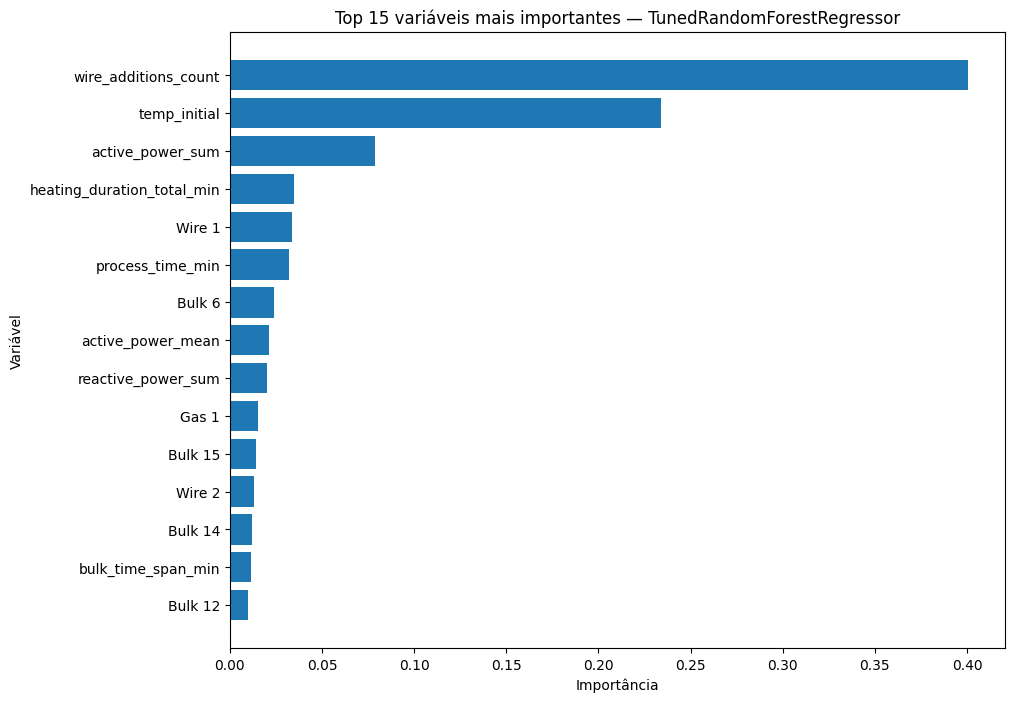

In [57]:
top_importance = importance_df.head(15).sort_values('importance')

plt.figure(figsize=[10, 8])
plt.barh(top_importance['feature'], top_importance['importance'])
plt.title(f'Top 15 variáveis mais importantes — {best_model_name}')
plt.xlabel('Importância')
plt.ylabel('Variável')
plt.show()

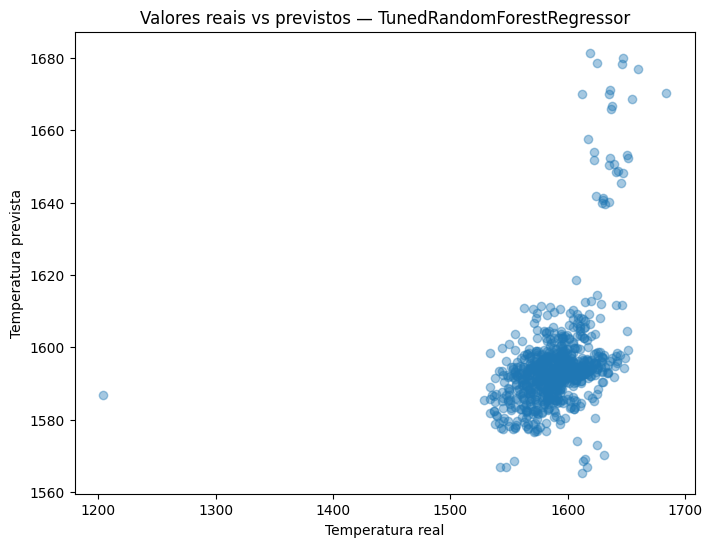

In [58]:
if best_model_name == 'TunedRandomForestRegressor':
    best_predictions = best_rf_pred
else:
    best_predictions = best_gbr_pred

plt.figure(figsize=[8, 6])
plt.scatter(y_test, best_predictions, alpha=0.4)
plt.title(f'Valores reais vs previstos — {best_model_name}')
plt.xlabel('Temperatura real')
plt.ylabel('Temperatura prevista')
plt.show()

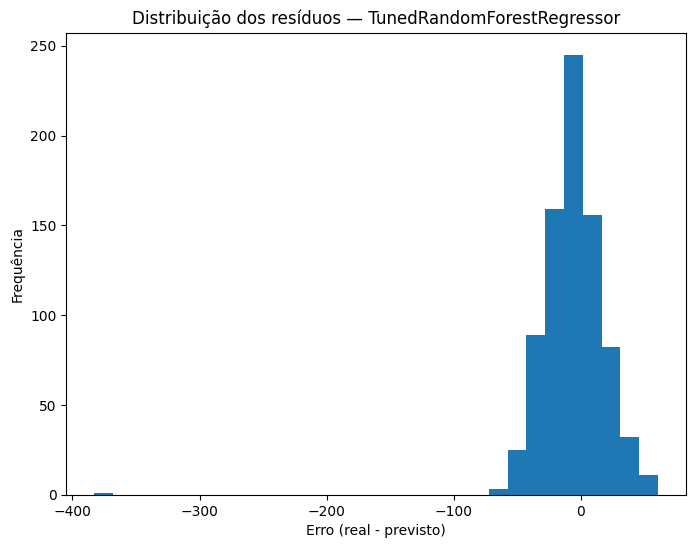

In [59]:
residuals = y_test - best_predictions

plt.figure(figsize=[8, 6])
plt.hist(residuals, bins=30)
plt.title(f'Distribuição dos resíduos — {best_model_name}')
plt.xlabel('Erro (real - previsto)')
plt.ylabel('Frequência')
plt.show()

## 16. Rodada adicional de melhoria

Os resultados obtidos até aqui mostraram que os modelos treinados superam o baseline, mas ainda não atingem os limiares de desempenho definidos no plano de trabalho.

Diante disso, será realizada uma rodada adicional de refinamento, com foco em **engenharia de atributos**. A ideia é enriquecer a representação do processo siderúrgico antes de testar novamente os modelos, especialmente em relação a:

- intensidade acumulada do aquecimento;
- características agregadas de adição de materiais;
- atributos derivados de tempo e sequência operacional;
- possível influência de valores extremos.

Como a limitação principal parece estar mais relacionada à qualidade dos atributos do que à escolha do algoritmo em si, esta etapa buscará extrair mais sinal preditivo dos dados já disponíveis.

## 17. Engenharia adicional de atributos

Nesta etapa, serão construídos atributos adicionais para representar melhor o processo físico e operacional do lote. O objetivo é resumir com mais precisão a intensidade do aquecimento, a carga de materiais adicionados e a relação temporal entre eventos de processo e medições de temperatura.

In [60]:
arc_agg_extra = data_arc.groupby('key').agg(
    arc_events=('key', 'count'),
    active_power_mean=('Active power', 'mean'),
    active_power_sum=('Active power', 'sum'),
    active_power_max=('Active power', 'max'),
    active_power_std=('Active power', 'std'),
    reactive_power_mean=('Reactive power', 'mean'),
    reactive_power_sum=('Reactive power', 'sum'),
    reactive_power_min=('Reactive power', 'min'),
    reactive_power_max=('Reactive power', 'max'),
    reactive_power_std=('Reactive power', 'std'),
    heating_duration_total_min=('heating_duration_min', 'sum'),
    heating_duration_mean_min=('heating_duration_min', 'mean'),
    heating_duration_max_min=('heating_duration_min', 'max')
).reset_index()

arc_agg_extra.head()

,key,arc_events,active_power_mean,active_power_sum,active_power_max,active_power_std,reactive_power_mean,reactive_power_sum,reactive_power_min,reactive_power_max,reactive_power_std,heating_duration_total_min,heating_duration_mean_min,heating_duration_max_min
0,1,5,0.98,4.88,1.66,0.40,0.64,3.18,0.41,1.06,0.26,18.30,3.66,6.08
1,2,4,0.76,3.05,1.30,0.40,0.50,2.00,0.28,0.89,0.28,13.52,3.38,5.63
2,3,5,0.51,2.53,1.06,0.33,0.32,1.60,0.16,0.67,0.21,10.92,2.18,4.67
3,4,4,0.80,3.21,1.22,0.33,0.52,2.06,0.27,0.75,0.21,12.35,3.09,4.63
4,5,4,0.84,3.35,1.62,0.59,0.56,2.25,0.18,1.05,0.39,14.48,3.62,6.92


In [61]:
data_arc['approx_energy'] = data_arc['Active power'] * data_arc['heating_duration_min']

arc_energy = data_arc.groupby('key').agg(
    approx_energy_sum=('approx_energy', 'sum'),
    approx_energy_mean=('approx_energy', 'mean'),
    approx_energy_max=('approx_energy', 'max')
).reset_index()

arc_energy.head()

,key,approx_energy_sum,approx_energy_mean,approx_energy_max
0,1,20.13,4.03,10.09
1,2,12.23,3.06,7.30
2,3,7.39,1.48,4.96
3,4,11.18,2.79,5.66
4,5,16.62,4.16,11.22


In [62]:
arc_time_features = data_arc.groupby('key').agg(
    first_arc_start=('Arc heating start', 'min'),
    last_arc_end=('Arc heating end', 'max')
).reset_index()

arc_time_features.head()

,key,first_arc_start,last_arc_end
0,1,2019-05-03 11:02:14,2019-05-03 11:28:37
1,2,2019-05-03 11:34:14,2019-05-03 11:53:18
2,3,2019-05-03 12:06:54,2019-05-03 12:32:19
3,4,2019-05-03 12:39:37,2019-05-03 12:57:50
4,5,2019-05-03 13:11:13,2019-05-03 13:33:55


In [63]:
temp_time_features = temp_features[['key', 'time_first_measurement', 'time_last_measurement']].copy()

time_relation_features = (
    temp_time_features
    .merge(arc_time_features, on='key', how='left')
)

time_relation_features['minutes_from_first_measurement_to_first_arc'] = (
    time_relation_features['first_arc_start'] - time_relation_features['time_first_measurement']
).dt.total_seconds() / 60

time_relation_features['minutes_from_last_arc_to_last_measurement'] = (
    time_relation_features['time_last_measurement'] - time_relation_features['last_arc_end']
).dt.total_seconds() / 60

time_relation_features.head()

,key,time_first_measurement,time_last_measurement,first_arc_start,last_arc_end,minutes_from_first_measurement_to_first_arc,minutes_from_last_arc_to_last_measurement
0,1,2019-05-03 11:16:18,2019-05-03 11:30:39,2019-05-03 11:02:14,2019-05-03 11:28:37,-14.07,2.03
1,2,2019-05-03 11:37:27,2019-05-03 11:59:12,2019-05-03 11:34:14,2019-05-03 11:53:18,-3.22,5.90
2,3,2019-05-03 12:13:17,2019-05-03 12:34:57,2019-05-03 12:06:54,2019-05-03 12:32:19,-6.38,2.63
3,4,2019-05-03 12:52:57,2019-05-03 12:59:25,2019-05-03 12:39:37,2019-05-03 12:57:50,-13.33,1.58
4,5,2019-05-03 13:23:19,2019-05-03 13:36:01,2019-05-03 13:11:13,2019-05-03 13:33:55,-12.10,2.10


In [64]:
bulk_cols = [col for col in data_bulk.columns if col != 'key']
wire_cols = [col for col in data_wire.columns if col != 'key']

bulk_features = data_bulk[['key']].copy()
wire_features = data_wire[['key']].copy()

bulk_features['bulk_total_sum'] = data_bulk[bulk_cols].fillna(0).sum(axis=1)
bulk_features['bulk_types_used'] = data_bulk[bulk_cols].notna().sum(axis=1)
bulk_features['bulk_mean_nonzero'] = data_bulk[bulk_cols].fillna(0).replace(0, np.nan).mean(axis=1).fillna(0)

wire_features['wire_total_sum'] = data_wire[wire_cols].fillna(0).sum(axis=1)
wire_features['wire_types_used'] = data_wire[wire_cols].notna().sum(axis=1)
wire_features['wire_mean_nonzero'] = data_wire[wire_cols].fillna(0).replace(0, np.nan).mean(axis=1).fillna(0)

bulk_features.head()

,key,bulk_total_sum,bulk_types_used,bulk_mean_nonzero
0,1,553.00,4,138.25
1,2,582.00,4,145.50
2,3,544.00,4,136.00
3,4,595.00,4,148.75
4,5,584.00,4,146.00


In [65]:
wire_features.head()

,key,wire_total_sum,wire_types_used,wire_mean_nonzero
0,1,60.06,1,60.06
1,2,96.05,1,96.05
2,3,91.16,1,91.16
3,4,89.06,1,89.06
4,5,98.35,2,49.18


In [66]:
material_totals = (
    bulk_features[['key', 'bulk_total_sum', 'bulk_types_used', 'bulk_mean_nonzero']]
    .merge(wire_features[['key', 'wire_total_sum', 'wire_types_used', 'wire_mean_nonzero']], on='key', how='outer')
)

material_totals['bulk_total_sum'] = material_totals['bulk_total_sum'].fillna(0)
material_totals['wire_total_sum'] = material_totals['wire_total_sum'].fillna(0)
material_totals['bulk_types_used'] = material_totals['bulk_types_used'].fillna(0)
material_totals['wire_types_used'] = material_totals['wire_types_used'].fillna(0)
material_totals['bulk_mean_nonzero'] = material_totals['bulk_mean_nonzero'].fillna(0)
material_totals['wire_mean_nonzero'] = material_totals['wire_mean_nonzero'].fillna(0)

material_totals['total_material_added'] = (
    material_totals['bulk_total_sum'] + material_totals['wire_total_sum']
)

material_totals.head()

,key,bulk_total_sum,bulk_types_used,bulk_mean_nonzero,wire_total_sum,wire_types_used,wire_mean_nonzero,total_material_added
0,1,553.00,4.00,138.25,60.06,1.00,60.06,613.06
1,2,582.00,4.00,145.50,96.05,1.00,96.05,678.05
2,3,544.00,4.00,136.00,91.16,1.00,91.16,635.16
3,4,595.00,4.00,148.75,89.06,1.00,89.06,684.06
4,5,584.00,4.00,146.00,98.35,2.00,49.18,682.35


In [67]:
enhanced_data = (
    temp_features
    .merge(arc_agg_extra, on='key', how='left')
    .merge(arc_energy, on='key', how='left')
    .merge(time_relation_features[['key', 'minutes_from_first_measurement_to_first_arc',
                                   'minutes_from_last_arc_to_last_measurement']], on='key', how='left')
    .merge(data_bulk, on='key', how='left')
    .merge(bulk_time_features, on='key', how='left')
    .merge(data_gas, on='key', how='left')
    .merge(data_wire, on='key', how='left')
    .merge(wire_time_features, on='key', how='left')
    .merge(material_totals, on='key', how='left')
)

enhanced_data.shape

(3216, 60)

In [68]:
enhanced_data.isna().sum().sort_values(ascending=False).head(40)

Bulk 8                  3215
Wire 5                  3215
Wire 7                  3205
Wire 4                  3202
Bulk 13                 3198
Bulk 9                  3197
Wire 8                  3197
Bulk 2                  3194
Bulk 7                  3191
Wire 9                  3187
Wire 3                  3153
Wire 6                  3143
Bulk 5                  3139
Bulk 10                 3040
Bulk 11                 3039
Bulk 1                  2964
Bulk 6                  2640
Bulk 4                  2202
Wire 2                  2137
Bulk 3                  1918
Bulk 15                  968
Bulk 12                  766
Bulk 14                  410
Wire 1                   161
wire_additions_count     135
wire_time_span_min       135
bulk_additions_count      87
bulk_time_span_min        87
reactive_power_std        41
active_power_std          41
wire_total_sum            31
bulk_mean_nonzero         31
bulk_types_used           31
bulk_total_sum            31
wire_types_use

A nova base consolidada incorpora atributos adicionais de intensidade de aquecimento, relações temporais e carga total de materiais adicionados. Em seguida, será repetido o processo de limpeza, seleção de variáveis e treinamento dos modelos para verificar se houve ganho de desempenho.

In [69]:
enhanced_missing_percent = (enhanced_data.isna().sum() / len(enhanced_data) * 100).sort_values(ascending=False)
enhanced_drop_cols = enhanced_missing_percent[enhanced_missing_percent >= 99].index.tolist()

enhanced_drop_cols

['Bulk 8',
 'Wire 5',
 'Wire 7',
 'Wire 4',
 'Bulk 13',
 'Bulk 9',
 'Wire 8',
 'Bulk 2',
 'Bulk 7',
 'Wire 9']

In [70]:
enhanced_clean = enhanced_data.drop(columns=enhanced_drop_cols).copy()
enhanced_clean.shape

(3216, 50)

In [71]:
enhanced_material_cols = [col for col in enhanced_clean.columns if col.startswith('Bulk ') or col.startswith('Wire ')]
enhanced_count_time_cols = [
    'bulk_additions_count', 'bulk_time_span_min',
    'wire_additions_count', 'wire_time_span_min',
    'bulk_total_sum', 'bulk_types_used', 'bulk_mean_nonzero',
    'wire_total_sum', 'wire_types_used', 'wire_mean_nonzero',
    'total_material_added'
]

for col in enhanced_material_cols:
    enhanced_clean[col] = enhanced_clean[col].fillna(0)

for col in enhanced_count_time_cols:
    if col in enhanced_clean.columns:
        enhanced_clean[col] = enhanced_clean[col].fillna(0)

In [72]:
enhanced_clean.isna().sum().sort_values(ascending=False).head(20)

reactive_power_std                             41
active_power_std                               41
heating_duration_mean_min                       2
reactive_power_min                              2
minutes_from_last_arc_to_last_measurement       2
minutes_from_first_measurement_to_first_arc     2
approx_energy_max                               2
approx_energy_mean                              2
approx_energy_sum                               2
heating_duration_max_min                        2
heating_duration_total_min                      2
reactive_power_max                              2
reactive_power_sum                              2
reactive_power_mean                             2
active_power_max                                2
active_power_sum                                2
active_power_mean                               2
arc_events                                      2
Gas 1                                           2
wire_time_span_min                              0


In [73]:
enhanced_clean = enhanced_clean.dropna().copy()
enhanced_clean.shape

(3173, 50)

In [74]:
enhanced_clean.isna().sum().sum()

0

In [75]:
enhanced_clean['temp_final'].describe(percentiles=[0.01, 0.05, 0.95, 0.99])

count   3173.00
mean    1593.91
std       19.92
min     1204.00
1%      1545.72
5%      1568.00
50%     1593.00
95%     1624.00
99%     1655.84
max     1700.00
Name: temp_final, dtype: float64

Antes de repetir a modelagem, será feita uma filtragem leve de valores extremos da variável-alvo, restringindo a análise ao intervalo entre os percentis 1% e 99%. O objetivo não é “melhorar artificialmente” o modelo, mas reduzir a influência de casos muito raros que podem representar situações atípicas ou pouco representativas do processo usual.

In [76]:
lower_bound = enhanced_clean['temp_final'].quantile(0.01)
upper_bound = enhanced_clean['temp_final'].quantile(0.99)

enhanced_filtered = enhanced_clean[
    (enhanced_clean['temp_final'] >= lower_bound) &
    (enhanced_clean['temp_final'] <= upper_bound)
].copy()

enhanced_filtered.shape

(3109, 50)

In [77]:
enhanced_filtered = enhanced_filtered.sort_values('time_last_measurement').reset_index(drop=True)

In [78]:
enhanced_columns_to_drop = [
    'key',
    'temp_final',
    'time_first_measurement',
    'time_last_measurement'
]

X_enhanced = enhanced_filtered.drop(columns=enhanced_columns_to_drop)
y_enhanced = enhanced_filtered['temp_final']

print(X_enhanced.shape)
print(y_enhanced.shape)

(3109, 46)
(3109,)


In [79]:
enhanced_split_index = int(len(enhanced_filtered) * 0.75)

X_train_enh = X_enhanced.iloc[:enhanced_split_index].copy()
X_test_enh = X_enhanced.iloc[enhanced_split_index:].copy()
y_train_enh = y_enhanced.iloc[:enhanced_split_index].copy()
y_test_enh = y_enhanced.iloc[enhanced_split_index:].copy()

print('Treino:', X_train_enh.shape, y_train_enh.shape)
print('Teste:', X_test_enh.shape, y_test_enh.shape)

Treino: (2331, 46) (2331,)
Teste: (778, 46) (778,)


In [80]:
dummy_enh = DummyRegressor(strategy='mean')
dummy_enh.fit(X_train_enh, y_train_enh)
dummy_enh_pred = dummy_enh.predict(X_test_enh)

dummy_enh_mae = mean_absolute_error(y_test_enh, dummy_enh_pred)
dummy_enh_rmse = mean_squared_error(y_test_enh, dummy_enh_pred, squared=False)
dummy_enh_r2 = r2_score(y_test_enh, dummy_enh_pred)

print('Enhanced Dummy Regressor')
print(f'MAE: {dummy_enh_mae:.2f}')
print(f'RMSE: {dummy_enh_rmse:.2f}')
print(f'R2: {dummy_enh_r2:.4f}')

Enhanced Dummy Regressor
MAE: 18.03
RMSE: 22.30
R2: -0.0240


In [81]:
linear_pipeline.fit(X_train_enh, y_train_enh)
linear_enh_pred = linear_pipeline.predict(X_test_enh)

linear_enh_mae = mean_absolute_error(y_test_enh, linear_enh_pred)
linear_enh_rmse = mean_squared_error(y_test_enh, linear_enh_pred, squared=False)
linear_enh_r2 = r2_score(y_test_enh, linear_enh_pred)

print('Enhanced Linear Regression')
print(f'MAE: {linear_enh_mae:.2f}')
print(f'RMSE: {linear_enh_rmse:.2f}')
print(f'R2: {linear_enh_r2:.4f}')

Enhanced Linear Regression
MAE: 16.28
RMSE: 20.58
R2: 0.1278


In [82]:
best_rf.fit(X_train_enh, y_train_enh)
best_rf_enh_pred = best_rf.predict(X_test_enh)

best_rf_enh_mae = mean_absolute_error(y_test_enh, best_rf_enh_pred)
best_rf_enh_rmse = mean_squared_error(y_test_enh, best_rf_enh_pred, squared=False)
best_rf_enh_r2 = r2_score(y_test_enh, best_rf_enh_pred)

print('Enhanced Tuned Random Forest Regressor')
print(f'MAE: {best_rf_enh_mae:.2f}')
print(f'RMSE: {best_rf_enh_rmse:.2f}')
print(f'R2: {best_rf_enh_r2:.4f}')

Enhanced Tuned Random Forest Regressor
MAE: 15.44
RMSE: 19.60
R2: 0.2090


In [83]:
best_gbr.fit(X_train_enh, y_train_enh)
best_gbr_enh_pred = best_gbr.predict(X_test_enh)

best_gbr_enh_mae = mean_absolute_error(y_test_enh, best_gbr_enh_pred)
best_gbr_enh_rmse = mean_squared_error(y_test_enh, best_gbr_enh_pred, squared=False)
best_gbr_enh_r2 = r2_score(y_test_enh, best_gbr_enh_pred)

print('Enhanced Tuned Gradient Boosting Regressor')
print(f'MAE: {best_gbr_enh_mae:.2f}')
print(f'RMSE: {best_gbr_enh_rmse:.2f}')
print(f'R2: {best_gbr_enh_r2:.4f}')

Enhanced Tuned Gradient Boosting Regressor
MAE: 15.62
RMSE: 19.86
R2: 0.1874


In [84]:
enhanced_results = pd.DataFrame({
    'model': [
        'EnhancedDummyRegressor',
        'EnhancedLinearRegression',
        'EnhancedTunedRandomForest',
        'EnhancedTunedGradientBoosting'
    ],
    'MAE': [
        dummy_enh_mae,
        linear_enh_mae,
        best_rf_enh_mae,
        best_gbr_enh_mae
    ],
    'RMSE': [
        dummy_enh_rmse,
        linear_enh_rmse,
        best_rf_enh_rmse,
        best_gbr_enh_rmse
    ],
    'R2': [
        dummy_enh_r2,
        linear_enh_r2,
        best_rf_enh_r2,
        best_gbr_enh_r2
    ]
})

enhanced_results.sort_values('MAE')

,model,MAE,RMSE,R2
2,EnhancedTunedRandomForest,15.44,19.60,0.21
3,EnhancedTunedGradientBoosting,15.62,19.86,0.19
1,EnhancedLinearRegression,16.28,20.58,0.13
0,EnhancedDummyRegressor,18.03,22.30,-0.02


## 18. Diagnóstico adicional de generalização

Como os modelos apresentaram desempenho substancialmente melhor na validação cruzada do que no conjunto de teste temporal, será realizado um teste diagnóstico com particionamento aleatório.

Esse experimento não substituirá a avaliação principal baseada em ordem temporal, mas ajudará a verificar se parte da dificuldade do problema está associada a mudanças de padrão ao longo do tempo. Caso os resultados melhorem sensivelmente com split aleatório, isso reforçará a hipótese de drift temporal no processo siderúrgico.

In [85]:
X_diag = enhanced_filtered.drop(columns=[
    'key',
    'temp_final',
    'time_first_measurement',
    'time_last_measurement'
])
y_diag = enhanced_filtered['temp_final']

X_train_diag, X_test_diag, y_train_diag, y_test_diag = train_test_split(
    X_diag,
    y_diag,
    test_size=0.25,
    random_state=42
)

print(X_train_diag.shape, X_test_diag.shape)

(2331, 46) (778, 46)


In [86]:
best_rf.fit(X_train_diag, y_train_diag)
rf_diag_pred = best_rf.predict(X_test_diag)

rf_diag_mae = mean_absolute_error(y_test_diag, rf_diag_pred)
rf_diag_rmse = mean_squared_error(y_test_diag, rf_diag_pred, squared=False)
rf_diag_r2 = r2_score(y_test_diag, rf_diag_pred)

print('Diagnostic Random Split — Tuned Random Forest')
print(f'MAE: {rf_diag_mae:.2f}')
print(f'RMSE: {rf_diag_rmse:.2f}')
print(f'R2: {rf_diag_r2:.4f}')

Diagnostic Random Split — Tuned Random Forest
MAE: 7.57
RMSE: 9.89
R2: 0.6030


In [87]:
best_gbr.fit(X_train_diag, y_train_diag)
gbr_diag_pred = best_gbr.predict(X_test_diag)

gbr_diag_mae = mean_absolute_error(y_test_diag, gbr_diag_pred)
gbr_diag_rmse = mean_squared_error(y_test_diag, gbr_diag_pred, squared=False)
gbr_diag_r2 = r2_score(y_test_diag, gbr_diag_pred)

print('Diagnostic Random Split — Tuned Gradient Boosting')
print(f'MAE: {gbr_diag_mae:.2f}')
print(f'RMSE: {gbr_diag_rmse:.2f}')
print(f'R2: {gbr_diag_r2:.4f}')

Diagnostic Random Split — Tuned Gradient Boosting
MAE: 7.47
RMSE: 9.74
R2: 0.6151


In [88]:
diagnostic_comparison = pd.DataFrame({
    'scenario': ['Temporal Split', 'Random Split', 'Temporal Split', 'Random Split'],
    'model': [
        'EnhancedTunedRandomForest',
        'EnhancedTunedRandomForest',
        'EnhancedTunedGradientBoosting',
        'EnhancedTunedGradientBoosting'
    ],
    'MAE': [
        best_rf_enh_mae,
        rf_diag_mae,
        best_gbr_enh_mae,
        gbr_diag_mae
    ],
    'RMSE': [
        best_rf_enh_rmse,
        rf_diag_rmse,
        best_gbr_enh_rmse,
        gbr_diag_rmse
    ],
    'R2': [
        best_rf_enh_r2,
        rf_diag_r2,
        best_gbr_enh_r2,
        gbr_diag_r2
    ]
})

diagnostic_comparison

,scenario,model,MAE,RMSE,R2
0,Temporal Split,EnhancedTunedRandomForest,15.44,19.60,0.21
1,Random Split,EnhancedTunedRandomForest,7.57,9.89,0.60
2,Temporal Split,EnhancedTunedGradientBoosting,15.62,19.86,0.19
3,Random Split,EnhancedTunedGradientBoosting,7.47,9.74,0.62


## 18.1 Interpretação do diagnóstico temporal

A comparação entre split temporal e split aleatório mostrou uma diferença expressiva de desempenho. Quando treino e teste foram separados de forma aleatória, os modelos atingiram erros muito menores e coeficientes de determinação substancialmente maiores. Já na avaliação temporal, em que o teste representa um período posterior ao treinamento, o desempenho caiu de forma acentuada.

Esse comportamento sugere que o processo industrial não permaneceu totalmente estável ao longo do tempo. Em outras palavras, os modelos conseguem aprender padrões úteis, mas esses padrões não generalizam tão bem para períodos futuros. Esse achado é compatível com a hipótese de drift temporal e reforça a importância de considerar atualização periódica do modelo em um cenário de aplicação real.

## 19. Conclusões e limitações

Nesta etapa, foi construída uma solução completa para prever a temperatura final do metal por lote na Steelproof, desde o carregamento e tratamento dos dados até a criação de modelos de regressão e comparação sistemática de desempenho.

A variável-alvo foi definida como a última temperatura medida em cada lote, e os atributos foram construídos a partir de informações de temperatura inicial, aquecimento elétrico, tempo de processo, uso de gás e adição de materiais a granel e em arame. Após a primeira rodada de modelagem, foi realizada uma etapa adicional de engenharia de atributos para enriquecer a representação do processo.

Na avaliação principal com **split temporal**, o melhor resultado foi obtido pelo **Random Forest ajustado**, com:
- **MAE = 15.44**
- **RMSE = 19.60**
- **R² = 0.21**

Esse desempenho supera o baseline e mostra que os dados possuem sinal preditivo útil. No entanto, ele permanece abaixo dos limiares originalmente definidos no plano de trabalho para a avaliação temporal.

Para aprofundar a interpretação dos resultados, foi realizado um experimento diagnóstico com **split aleatório**, utilizando a mesma base enriquecida. Nesse cenário, os modelos apresentaram desempenho muito superior:
- **Random Forest ajustado:** MAE = 7.57, RMSE = 9.89, R² = 0.60
- **Gradient Boosting ajustado:** MAE = 7.47, RMSE = 9.74, R² = 0.62

Esses resultados indicam que os atributos construídos são capazes de capturar bem a relação entre as variáveis de processo e a temperatura final quando treino e teste pertencem a distribuições semelhantes. Por outro lado, a diferença acentuada entre o desempenho no split aleatório e no split temporal sugere fortemente a presença de **drift temporal**, isto é, mudança de padrão operacional ao longo do tempo.

Assim, a principal conclusão do projeto não é apenas qual modelo teve o menor erro, mas também que a **estabilidade temporal do processo** é um fator crítico para a qualidade preditiva. Em um cenário industrial real, isso significa que modelos treinados em dados históricos podem perder desempenho quando aplicados a períodos futuros caso o processo produtivo sofra mudanças de regime, ajustes operacionais ou variações não representadas no treinamento.

As principais limitações encontradas foram:
- esparsidade elevada em diversas colunas de materiais;
- possível ausência de variáveis relevantes para o balanço térmico;
- sensibilidade do modelo à mudança temporal do processo;
- necessidade de monitoramento contínuo e possível re-treinamento periódico em produção.

Como próximos passos, seria recomendável:
1. investigar mais profundamente a mudança temporal no processo;
2. incluir novas variáveis operacionais, se disponíveis;
3. testar estratégias de atualização contínua do modelo;
4. avaliar janelas móveis de treinamento para reduzir o impacto do drift temporal.

<div class="alert alert-block alert-warning">
<b> Comentário do revisor: </b> <a class="tocSkip"></a>
    
- Bom trabalho com o processo de treinamento acima. Destaco alguns pontos positivos:
    - Você treinou diversos modelos com hiperparâmetros padrão. Como sugestão, você poderia utilizar métodos como `RandomizedSearchCV` ou métodos bayesianos como `optuna` (que é ainda mais eficiente) para estudo de hiperparâmetros de maneira automatizada.
    - Você poderia criar uma função para organizar o seu código do estudo de hiperparâmetros para reutilizar parte da lógica que se repete entre os experimentos ao invés de criar um método para cada experimento. Por exemplo, você poderia criar um método "boilerplate" que recebe o modelo e mapeia para os hiperparâmetros deste modelo através de um dicionário um tupla no Python.
    - Além disso, procure testar com modelos de diferentes famílias. Experimentar com apenas um modelo de `boosting` já é suficiente e você poderia aproveitar para testar outros tipos de modelos, como Regressão Logística, etc.
    - Por fim, você poderia criar um método para centralizar a etapa de validação cruzada para evitar repetição de código. Embora seja aceitável fazer métodos autocontidos em jupyter notebooks, pense em como esse modelo vai para produção em uma etapa posterior. Ter o código mais perto de "produção" vai te ajudar nessa transição.
</div>